# Phase 18 — Cross-Dataset LoRA Transfer with CDML

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification
**Author:** Milani, S. — University of Padova

---

## Design

```
PHASE 1 — Backbone pre-training (Dataset 1, standard supervised training)
─────────────────────────────────────────────────────────────────────────
  All 118 subjects, all windows, one training run (no continual learning).
  Architecture: Conv1d × 4  →  AdaptiveAvgPool1d  →  Linear(flat, 128)
  Output: frozen backbone weights  W_cnn  +  W_emb

PHASE 2 — Continual learning on target datasets (UCI HAR, WISDM)
─────────────────────────────────────────────────────────────────────────
  For each dataset independently:

  Input → [FROZEN] CNN → [FROZEN] W_emb + [TRAINED] LoRA(Aₖ, Bₖ) → h
                                                                     ↓
                                                           CDMLLayer (seed_k)
                                                                     ↓
                                   [FROZEN after T1] Linear(128 → N_classes)
                                                                     ↓
                                                                  logits

  Task 1 : train  LoRA(A₁,B₁)  +  classifier head
  Tasks 2-4 : train  LoRA(Aₖ,Bₖ)  only  (classifier frozen)
  Backbone CNN + W_emb : ALWAYS frozen
```

### Key differences vs Phase 15

| | Phase 15 | Phase 16 |
|---|---|---|
| Backbone source | Trained on Task 1 of same dataset | Pre-trained on full Dataset 1 |
| Backbone frozen from | After Task 1 | From the very start |
| Phase 1 training | Continual (4 tasks) | Standard (whole dataset at once) |
| LoRA target | Embedding + classifier | Embedding only |
| Classifier | LoRALinear (transferred W) | Fresh `nn.Linear` (frozen after T1) |

> **v2 — Fixes applied**
> 1. `_run_epoch`: added `model.feature_extractor.eval()` after `model.train()` — prevents BatchNorm running statistics from drifting during Tasks 2-4, which was the primary cause of the catastrophic Task-1 accuracy collapse on WISDM (93 % → 17 %).
> 2. `train_lora_transfer`: classifier head is now kept trainable for **all** tasks (not just Task 1). The original frozen-classifier design left neurons 13-50 (WISDM) / 8-29 (UCI) as random, untrained weights — LoRA adapters for Tasks 2-4 could not meaningfully use them. CDML's per-task modulation sequences provide the anti-forgetting protection instead.



## 0. Imports

In [1]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset
)
from copy import deepcopy
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

DEVICE = torch.device('cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device : cpu
PyTorch: 2.8.0


## 1. Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
D1_TRAIN_DIR = '../Data/Dataset_1/train'
D1_TEST_DIR  = '../Data/Dataset_1/test'
UCI_DATA_DIR = '../Data/UCI HAR Dataset'
WSD_DATA_DIR = '../Data/wisdm-dataset'

# ── Sensor / model ────────────────────────────────────────────────────────────
N_CHANNELS    = 6
EMBED_DIM     = 128
ADAPTIVE_SIZE = 8          # AdaptiveAvgPool1d output; flat = 128 × 8 = 1024

# ── LoRA ──────────────────────────────────────────────────────────────────────
LORA_RANK  = 8
LORA_ALPHA = 8             # scaling = alpha / rank = 1.0

# ── CDML ──────────────────────────────────────────────────────────────────────
CDML_SEED_BASE = 1000      # seed for task k = CDML_SEED_BASE + k

# ── Training ──────────────────────────────────────────────────────────────────
RANDOM_SEED    = 27
BATCH_SIZE     = 64
VAL_SPLIT      = 0.15

EPOCHS_PHASE1  = 50        # Phase 1: standard CNN pre-training on Dataset 1
EPOCHS_PHASE2  = 50       # Phase 2: LoRA continual learning on target datasets
LR_INIT        = 1e-3
LR_DECAY       = 0.98

# ── Dataset 1 (118 subjects, window 128) ──────────────────────────────────────
D1_WINDOW_SIZE = 128
D1_N_CLASSES   = 118
D1_TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── UCI HAR (30 subjects, window 128) ─────────────────────────────────────────
UCI_N_CLASSES  = 30
UCI_TASK_SPLITS = {
    'Task 1': (1,   8),
    'Task 2': (9,  17),
    'Task 3': (18, 24),
    'Task 4': (25, 30),
}

# ── WISDM (51 subjects, window 200 — handled by adaptive pooling) ─────────────
WSD_WINDOW_SIZE = 200
WSD_N_CLASSES   = 51
WSD_TASK_SPLITS = {
    'Task 1': (1,  13),
    'Task 2': (14, 26),
    'Task 3': (27, 39),
    'Task 4': (40, 51),
}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuration ready.')
print(f'  AdaptiveAvgPool1d({ADAPTIVE_SIZE})  →  flat dim = {128 * ADAPTIVE_SIZE}')
print(f'  LoRA rank={LORA_RANK}, alpha={LORA_ALPHA}, scaling={LORA_ALPHA/LORA_RANK:.2f}')
lora_params = LORA_RANK * (128 * ADAPTIVE_SIZE + EMBED_DIM)
print(f'  LoRA adapter params per task (embedding only): {lora_params:,}')


Configuration ready.
  AdaptiveAvgPool1d(8)  →  flat dim = 1024
  LoRA rank=8, alpha=8, scaling=1.00
  LoRA adapter params per task (embedding only): 9,216


## 2. Model Building Blocks

### 2.1 ConvBlock, CDML

In [3]:
class ConvBlock(nn.Module):
    """Conv1d → BatchNorm → ReLU → MaxPool1d."""
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


def generate_cdml_sequence(embed_dim, seed):
    """Deterministic ±1 sequence from seed — never stored alongside raw data."""
    rng = np.random.default_rng(seed)
    return torch.tensor(
        np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))


class CDMLLayer(nn.Module):
    """Element-wise modulation  m = s_k ⊙ h."""
    def __init__(self, embed_dim, seed=CDML_SEED_BASE):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h):
        return h * self.sequence


print('ConvBlock, CDMLLayer defined.')


ConvBlock, CDMLLayer defined.


### 2.2 LoRALinear

In [4]:
class LoRALinear(nn.Module):
    """
    Linear layer with Low-Rank Adaptation (Hu et al. 2021).

      Forward:  y = W·x + b  +  (B_k · A_k)·x  ×  (alpha / rank)

    W and b are the base (frozen) weights — shared across all tasks.
    A_k, B_k are task-specific adapters: freshly initialised, trained,
    saved per task, and swapped in/out during evaluation.
    """
    def __init__(self, in_features, out_features,
                 rank=LORA_RANK, alpha=LORA_ALPHA, bias=True):
        super().__init__()
        self.rank    = rank
        self.scaling = alpha / rank

        self.weight = nn.Parameter(
            nn.init.kaiming_uniform_(
                torch.empty(out_features, in_features), a=np.sqrt(5)))
        if bias:
            bound = 1 / np.sqrt(in_features) if in_features > 0 else 0
            self.bias = nn.Parameter(
                torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter('bias', None)

        # LoRA adapter matrices (re-initialised before every task)
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))

        self._lora_states: dict = {}   # {task_name: (A_cpu, B_cpu)}

    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base + lora

    # ── adapter management ────────────────────────────────────────────────────
    def save_lora(self, task_name):
        self._lora_states[task_name] = (
            self.lora_A.data.cpu().clone(),
            self.lora_B.data.cpu().clone())

    def load_lora(self, task_name):
        A, B = self._lora_states[task_name]
        self.lora_A.data.copy_(A.to(self.lora_A.device))
        self.lora_B.data.copy_(B.to(self.lora_B.device))

    def reset_lora(self):
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    # ── freezing helpers ──────────────────────────────────────────────────────
    def freeze_base(self):
        self.weight.requires_grad_(False)
        if self.bias is not None:
            self.bias.requires_grad_(False)

    def lora_parameters(self):
        return [self.lora_A, self.lora_B]


print('LoRALinear defined.')
print(f'  Adapter params per task (embedding, rank={LORA_RANK}): '
      f'{LORA_RANK * (128 * ADAPTIVE_SIZE + EMBED_DIM):,}')


LoRALinear defined.
  Adapter params per task (embedding, rank=8): 9,216


### 2.3 Phase 1 backbone — `GaitCNN`

Plain CNN used for Dataset 1 pre-training.
No LoRA, no CDML.  `AdaptiveAvgPool1d` makes the flat dimension
independent of window size so the same weights transfer to any dataset.

```
Input (N, 6, T)
  → ConvBlock(6→32) → ConvBlock(32→64) → ConvBlock(64→128) → ConvBlock(128→128)
  → AdaptiveAvgPool1d(8)          # always outputs (N, 128, 8)
  → Flatten                       # (N, 1024)
  → Linear(1024, 128)             # embedding layer W_emb
  → Linear(128, 118)              # classifier  (only used during pre-training)
```


In [5]:
class GaitCNN(nn.Module):
    """
    Standard CNN for Dataset 1 pre-training.
    The feature_extractor and embedding are later transferred (frozen)
    to GaitCNN_LoRA_Transfer for Phase 2.
    """
    def __init__(self, n_channels=N_CHANNELS, n_classes=D1_N_CLASSES,
                 embed_dim=EMBED_DIM, adaptive_size=ADAPTIVE_SIZE):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 128),
            nn.AdaptiveAvgPool1d(adaptive_size),
            nn.Flatten(),
        )
        flat = 128 * adaptive_size   # 1024

        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(F.relu(self.embed(x)))


# Verify with both window sizes
for ws, tag in [(128, 'Dataset 1 / UCI HAR'), (200, 'WISDM')]:
    m = GaitCNN()
    y = m(torch.zeros(2, N_CHANNELS, ws))
    print(f'  Window {ws:>3} ({tag}):  output {y.shape}  ✓')
del m


  Window 128 (Dataset 1 / UCI HAR):  output torch.Size([2, 118])  ✓
  Window 200 (WISDM):  output torch.Size([2, 118])  ✓


### 2.4 Phase 2 model — `GaitCNN_LoRA_Transfer`

The backbone (CNN + embedding W) is copied from the pre-trained `GaitCNN`
and immediately frozen.  A `LoRALinear` wrapping replaces the plain
`nn.Linear` embedding so that LoRA adapters can be attached on top of
the frozen W.

```
Input → [FROZEN] feature_extractor
      → [FROZEN W] LoRALinear embedding  +  [TRAINED] (Aₖ, Bₖ)  →  h
      → CDMLLayer  (sequence sₖ = f(seed_k))                     →  m
      → [FROZEN after T1] nn.Linear classifier                   →  logits
```

**Trainable parameters per task:**

| Task | Trained |
|---|---|
| T1 | LoRA adapters (A₁, B₁) + classifier head |
| T2–T4 | LoRA adapters (Aₖ, Bₖ) only |


In [6]:
class GaitCNN_LoRA_Transfer(nn.Module):
    """
    Transfer model for Phase 2.

    Accepts a pre-trained GaitCNN, copies its feature_extractor and
    embedding weights into a frozen LoRALinear, then attaches a CDML
    layer and a fresh classifier head for the target dataset.
    """
    def __init__(self, pretrained: GaitCNN,
                 n_classes: int,
                 embed_dim: int = EMBED_DIM,
                 lora_rank: int = LORA_RANK,
                 lora_alpha: int = LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.seeds: dict = {}
        self._classifier_frozen = False

        # ── Frozen feature extractor (from Dataset 1) ─────────────────────
        self.feature_extractor = deepcopy(pretrained.feature_extractor)
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)

        # ── LoRALinear embedding: copy W from pre-trained, freeze it ──────
        flat = 128 * ADAPTIVE_SIZE
        self.embedding = LoRALinear(flat, embed_dim, rank=lora_rank, alpha=lora_alpha)
        # Transfer pre-trained weights into the base weight
        with torch.no_grad():
            self.embedding.weight.copy_(pretrained.embedding.weight.data)
            self.embedding.bias.copy_(pretrained.embedding.bias.data)
        self.embedding.freeze_base()   # W and b frozen; only A_k, B_k trainable
        self.embedding.reset_lora()    # fresh A_1, B_1 ready for Task 1

        # ── CDML layer ────────────────────────────────────────────────────
        self.cdml = CDMLLayer(embed_dim)

        # ── Fresh classifier head for target dataset ──────────────────────
        # Trained on Task 1 alongside LoRA adapters, then frozen.
        self.classifier = nn.Linear(embed_dim, n_classes)

    # ── Forward ──────────────────────────────────────────────────────────────
    def embed(self, x):
        """h = LoRALinear( feature_extractor(x) ) — before CDML."""
        return F.relu(self.embedding(self.feature_extractor(x)))

    def forward(self, x):
        h = self.embed(x)
        m = self.cdml(h)
        return self.classifier(m)

    # ── CDML sequence ─────────────────────────────────────────────────────────
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        dev = next(self.parameters()).device
        self.cdml.sequence = generate_cdml_sequence(self.embed_dim, seed).to(dev)

    # ── LoRA adapter management ───────────────────────────────────────────────
    def save_lora(self, task_name):
        self.embedding.save_lora(task_name)

    def load_lora(self, task_name):
        self.embedding.load_lora(task_name)

    def reset_lora(self):
        self.embedding.reset_lora()

    # ── Classifier freeze ─────────────────────────────────────────────────────
    def freeze_classifier(self):
        for p in self.classifier.parameters():
            p.requires_grad_(False)
        self._classifier_frozen = True
        print('  Classifier head frozen — Tasks 2+ will update LoRA adapters only.')

    # ── Parameter helpers ─────────────────────────────────────────────────────
    def lora_parameters(self):
        """Only the LoRA adapter tensors (A_k, B_k)."""
        return self.embedding.lora_parameters()

    def task1_parameters(self):
        """LoRA adapters + classifier head (trained jointly on Task 1)."""
        return self.lora_parameters() + list(self.classifier.parameters())

    def n_trainable(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def n_frozen(self):
        return sum(p.numel() for p in self.parameters() if not p.requires_grad)


print('GaitCNN_LoRA_Transfer defined.')


GaitCNN_LoRA_Transfer defined.


## 3. Training Utilities

In [7]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total if total > 0 else 0.0


def _run_epoch(model, loader, optimizer, criterion, device,
               task_name=None, seed=None):
    """Single training epoch.  Sets CDML sequence when task_name is given.

    FIX (BatchNorm contamination): model.train() sets ALL submodules —
    including the frozen feature_extractor — to training mode, which causes
    BatchNorm's running_mean / running_var buffers to drift toward the
    current task's data distribution.  Those buffers are *not* protected by
    requires_grad=False (they are registered as buffers, not parameters).
    After a few hundred batches the statistics no longer match what Task 1
    trained on, so restoring LoRA(A1,B1) still produces wrong features —
    causing the observed 93 % → 17 % collapse on WISDM.

    Fix: immediately call model.feature_extractor.eval() after model.train()
    so the frozen CNN always uses its pre-trained running statistics.
    """
    model.train()
    model.feature_extractor.eval()   # keep BN running stats frozen

    if task_name is not None and seed is not None:
        model.set_task_sequence(task_name, seed)
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        criterion(model(X_b), y_b).backward()
        optimizer.step()


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device):
    """Evaluate on all tasks seen so far, restoring per-task LoRA + CDML state."""
    model.eval()
    current = task_names[step_idx]
    for ei, et in enumerate(task_names[:step_idx + 1]):
        if et in model.seeds:
            model.set_task_sequence(et, model.seeds[et])
        model.load_lora(et)
        loader = DataLoader(task_data[et]['test'], batch_size=256, shuffle=False)
        acc_matrix[step_idx, ei] = evaluate(model, loader, device)
    # restore current task state
    model.set_task_sequence(current, model.seeds[current])
    model.load_lora(current)


print('Utilities defined.')


Utilities defined.


## 4. Data Loading

### 4.1 Dataset 1 — full dataset (Phase 1 training)

In [8]:
def _load_d1_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt')
               for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)   # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y


print('Loading Dataset 1...')
X_tr_d1, y_tr_d1 = _load_d1_split(D1_TRAIN_DIR, 'train')
X_te_d1, y_te_d1 = _load_d1_split(D1_TEST_DIR,  'test')

# Normalise per channel
ch_mean = X_tr_d1.mean(axis=(0, 2), keepdims=True)
ch_std  = X_tr_d1.std(axis=(0, 2),  keepdims=True) + 1e-8
X_tr_d1_n = (X_tr_d1 - ch_mean) / ch_std
X_te_d1_n = (X_te_d1 - ch_mean) / ch_std

# Map subject IDs to 0-based indices
unique_d1    = np.sort(np.unique(np.concatenate([y_tr_d1, y_te_d1])))
lbl2idx_d1   = {l: i for i, l in enumerate(unique_d1)}
y_tr_d1_idx  = np.array([lbl2idx_d1[l] for l in y_tr_d1])
y_te_d1_idx  = np.array([lbl2idx_d1[l] for l in y_te_d1])

# Single train / val split (no task structure needed for Phase 1)
n_val_d1  = max(1, int(len(X_tr_d1_n) * VAL_SPLIT))
n_tr_d1   = len(X_tr_d1_n) - n_val_d1
gen       = torch.Generator().manual_seed(RANDOM_SEED)
full_d1   = TensorDataset(torch.tensor(X_tr_d1_n),
                           torch.tensor(y_tr_d1_idx, dtype=torch.long))
train_d1, val_d1 = random_split(full_d1, [n_tr_d1, n_val_d1], generator=gen)
test_d1   = TensorDataset(torch.tensor(X_te_d1_n),
                           torch.tensor(y_te_d1_idx, dtype=torch.long))

print(f'  Train: {len(train_d1):,}  |  Val: {len(val_d1):,}  |  Test: {len(test_d1):,}')
print(f'  Classes: {D1_N_CLASSES}  |  Window: {D1_WINDOW_SIZE}  |  Channels: {N_CHANNELS}')


Loading Dataset 1...
  Train: 28,139  |  Val: 4,965  |  Test: 3,740
  Classes: 118  |  Window: 128  |  Channels: 6


### 4.2 Target datasets — task-structured (Phase 2)

In [9]:
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx,
                        X_te, y_te_orig, y_te_idx,
                        task_splits, val_split=VAL_SPLIT, seed=RANDOM_SEED):
    """
    Build a dict  {task_name: {train, val, test}}  by filtering subjects.
    Labels are remapped to 0-based within each task's subject range.
    """
    gen = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t  = torch.tensor(X_tr[mask_tr])
        y_t  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_v  = max(1, int(len(full) * val_split))
        tr_ds, val_ds = random_split(full, [len(full) - n_v, n_v], generator=gen)

        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        te_ds   = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))

        task_data[task_name] = {'train': tr_ds, 'val': val_ds, 'test': te_ds}
        n_subj = hi - lo + 1
        print(f'  {task_name} (subjects {lo}-{hi}, {n_subj}): '
              f'{len(tr_ds)} train | {n_v} val | {len(te_ds)} test')
    return task_data


# ── UCI HAR ───────────────────────────────────────────────────────────────────
print('\nLoading UCI HAR...')
def _load_uci(data_dir, prefix):
    axes = ['total_acc_x', 'total_acc_y', 'total_acc_z',
            'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    signals = [
        np.loadtxt(f'{data_dir}/{prefix}/Inertial Signals/{a}_{prefix}.txt')
        for a in axes]
    X        = np.stack(signals, axis=1).astype(np.float32)
    subjects = np.loadtxt(f'{data_dir}/{prefix}/subject_{prefix}.txt', dtype=int)
    return X, subjects

X_tr_uci_raw, y_tr_uci_raw = _load_uci(UCI_DATA_DIR, 'train')
X_te_uci_raw, y_te_uci_raw = _load_uci(UCI_DATA_DIR, 'test')

# FIX: Merge the mutually exclusive datasets first
X_uci_full = np.concatenate([X_tr_uci_raw, X_te_uci_raw], axis=0)
y_uci_full = np.concatenate([y_tr_uci_raw, y_te_uci_raw], axis=0)

# FIX: Split properly so all subjects exist in both train and test
idx_tr_uci, idx_te_uci = train_test_split(
    np.arange(len(X_uci_full)), test_size=0.20, stratify=y_uci_full, random_state=RANDOM_SEED)

X_tr_uci, y_tr_uci = X_uci_full[idx_tr_uci], y_uci_full[idx_tr_uci]
X_te_uci, y_te_uci = X_uci_full[idx_te_uci], y_uci_full[idx_te_uci]

# Normalization
cm_uci = X_tr_uci.mean(axis=(0,2), keepdims=True)
cs_uci = X_tr_uci.std(axis=(0,2),  keepdims=True) + 1e-8
X_tr_uci_n = (X_tr_uci - cm_uci) / cs_uci
X_te_uci_n = (X_te_uci - cm_uci) / cs_uci

u_uci = np.sort(np.unique(np.concatenate([y_tr_uci, y_te_uci])))
l2i_uci = {l: i for i, l in enumerate(u_uci)}
y_tr_uci_idx = np.array([l2i_uci[l] for l in y_tr_uci])
y_te_uci_idx = np.array([l2i_uci[l] for l in y_te_uci])

task_data_uci  = make_task_datasets(X_tr_uci_n, y_tr_uci, y_tr_uci_idx,
                                     X_te_uci_n, y_te_uci, y_te_uci_idx,
                                     UCI_TASK_SPLITS)
task_names_uci = list(UCI_TASK_SPLITS.keys())
print(f'UCI HAR: window={X_tr_uci.shape[-1]}, {UCI_N_CLASSES} subjects')

# ── WISDM ─────────────────────────────────────────────────────────────────────
print('\nLoading WISDM...')
def _load_wisdm(data_dir, window_size=WSD_WINDOW_SIZE, step=None):
    if step is None:
        step = window_size // 2
    accel_dir = os.path.join(data_dir, 'raw', 'phone', 'accel')
    gyro_dir  = os.path.join(data_dir, 'raw', 'phone', 'gyro')
    sids = sorted(set(
        int(re.search(r'data_(\d+)_', f).group(1))
        for f in os.listdir(accel_dir) if f.endswith('.txt')))
    X_list, y_list = [], []
    for sid in sids:
        def _read(folder):
            files = glob.glob(os.path.join(folder, f'data_{sid}_*.txt'))
            if not files: return None
            rows = []
            with open(files[0]) as fh:
                for line in fh:
                    parts = line.strip().rstrip(';').split(',')
                    if len(parts) >= 5:
                        try: rows.append([float(v) for v in parts[2:5]])
                        except ValueError: pass
            return np.array(rows, dtype=np.float32) if rows else None
        acc, gyr = _read(accel_dir), _read(gyro_dir)
        if acc is None or gyr is None: continue
        n = min(len(acc), len(gyr))
        sig = np.concatenate([acc[:n], gyr[:n]], axis=1).T   # (6, T)
        for s in range(0, sig.shape[1] - window_size + 1, step):
            X_list.append(sig[:, s:s + window_size])
            y_list.append(sid - min(sids) + 1)
    return np.stack(X_list).astype(np.float32), np.array(y_list, dtype=int)

X_wsd, y_wsd = _load_wisdm(WSD_DATA_DIR)
idx_tr, idx_te = train_test_split(
    np.arange(len(X_wsd)), test_size=0.20, stratify=y_wsd, random_state=RANDOM_SEED)
X_tr_wsd, y_tr_wsd = X_wsd[idx_tr], y_wsd[idx_tr]
X_te_wsd, y_te_wsd = X_wsd[idx_te], y_wsd[idx_te]

cm_wsd = X_tr_wsd.mean(axis=(0,2), keepdims=True)
cs_wsd = X_tr_wsd.std(axis=(0,2),  keepdims=True) + 1e-8
X_tr_wsd_n = (X_tr_wsd - cm_wsd) / cs_wsd
X_te_wsd_n = (X_te_wsd - cm_wsd) / cs_wsd

u_wsd = np.sort(np.unique(np.concatenate([y_tr_wsd, y_te_wsd])))
l2i_wsd = {l: i for i, l in enumerate(u_wsd)}
y_tr_wsd_idx = np.array([l2i_wsd[l] for l in y_tr_wsd])
y_te_wsd_idx = np.array([l2i_wsd[l] for l in y_te_wsd])

task_data_wsd  = make_task_datasets(X_tr_wsd_n, y_tr_wsd, y_tr_wsd_idx,
                                     X_te_wsd_n, y_te_wsd, y_te_wsd_idx,
                                     WSD_TASK_SPLITS)
task_names_wsd = list(WSD_TASK_SPLITS.keys())
print(f'WISDM:   window={WSD_WINDOW_SIZE}, {WSD_N_CLASSES} subjects  '
      f'→ AdaptiveAvgPool1d({ADAPTIVE_SIZE}) → flat=1024  ✓')



Loading UCI HAR...
  Task 1 (subjects 1-8, 8): 1717 train | 303 val | 503 test
  Task 2 (subjects 9-17, 9): 1992 train | 351 val | 587 test
  Task 3 (subjects 18-24, 7): 1741 train | 307 val | 512 test
  Task 4 (subjects 25-30, 6): 1554 train | 274 val | 458 test
UCI HAR: window=128, 30 subjects

Loading WISDM...
  Task 1 (subjects 1-13, 13): 6075 train | 1071 val | 1785 test
  Task 2 (subjects 14-26, 13): 6072 train | 1071 val | 1784 test
  Task 3 (subjects 27-39, 13): 6151 train | 1085 val | 1807 test
  Task 4 (subjects 40-51, 12): 6189 train | 1092 val | 1826 test
WISDM:   window=200, 51 subjects  → AdaptiveAvgPool1d(8) → flat=1024  ✓


## 5. Phase 1 — Standard CNN Pre-training on Dataset 1

A plain `GaitCNN` is trained on the **entire** Dataset 1 in a single run
(no continual learning, no task splits).  This gives the backbone maximum
exposure to all 118 subjects' gait patterns before any freezing occurs.

After training the backbone weights are fixed and never updated again.


In [10]:
def train_phase1(train_ds, val_ds, device,
                 n_classes=D1_N_CLASSES,
                 epochs=EPOCHS_PHASE1,
                 lr=LR_INIT, lr_decay=LR_DECAY,
                 batch_size=BATCH_SIZE,
                 verbose_every=10):
    """Standard supervised training of GaitCNN on Dataset 1."""
    torch.manual_seed(RANDOM_SEED)
    model     = GaitCNN(N_CHANNELS, n_classes, EMBED_DIM, ADAPTIVE_SIZE).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader= DataLoader(val_ds,   batch_size=256, shuffle=False)

    print('=' * 60)
    print('PHASE 1 — Dataset 1 backbone pre-training')
    print(f'  Total params: {sum(p.numel() for p in model.parameters()):,}')
    print('=' * 60)

    best_val, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()
        scheduler.step()
        if epoch % verbose_every == 0 or epoch == 1:
            val_acc = evaluate(model, val_loader, device)
            if val_acc > best_val:
                best_val   = val_acc
                best_state = deepcopy(model.state_dict())
            print(f'  Epoch {epoch:>3}/{epochs}  val={val_acc:.4f}  (best={best_val:.4f})')

    model.load_state_dict(best_state)
    print(f'\nPhase 1 complete. Best val accuracy: {best_val:.4f}')
    print('Backbone ready for transfer (will be frozen in Phase 2).')
    return model


pretrained_cnn = train_phase1(train_d1, val_d1, DEVICE)


PHASE 1 — Dataset 1 backbone pre-training
  Total params: 227,926
  Epoch   1/50  val=0.9492  (best=0.9492)
  Epoch  10/50  val=0.9732  (best=0.9732)
  Epoch  20/50  val=0.9857  (best=0.9857)
  Epoch  30/50  val=0.9893  (best=0.9893)
  Epoch  40/50  val=0.9887  (best=0.9893)
  Epoch  50/50  val=0.9865  (best=0.9893)

Phase 1 complete. Best val accuracy: 0.9893
Backbone ready for transfer (will be frozen in Phase 2).


In [11]:
# Final test accuracy on Dataset 1
test_loader_d1 = DataLoader(test_d1, batch_size=256)
test_acc_d1    = evaluate(pretrained_cnn, test_loader_d1, DEVICE)
print(f'Dataset 1 test accuracy (Phase 1 backbone): {test_acc_d1:.4f}')


Dataset 1 test accuracy (Phase 1 backbone): 0.9412


## 6. Phase 2 — Continual Learning with Frozen Backbone + LoRA + CDML

`train_lora_transfer` runs 4 continual tasks on a target dataset:

| Task | Trainable | Frozen |
|---|---|---|
| T1 | LoRA (A₁, B₁) + classifier head | CNN, W_emb |
| T2-T4 | LoRA (Aₖ, Bₖ) | CNN, W_emb, classifier head |

After each task the LoRA adapters are saved.
At evaluation time, for each task `k` we load `(Aₖ, Bₖ)` and set the
CDML sequence to `f(seed_k)` before inference.


In [12]:
def train_lora_transfer(task_data, task_names, n_classes, pretrained,
                         device, epochs=EPOCHS_PHASE2,
                         lr=LR_INIT, lr_decay=LR_DECAY,
                         batch_size=BATCH_SIZE,
                         verbose_every=20, label='LoRA-Transfer'):
    """
    Continual learning on a target dataset using a frozen Dataset-1 backbone.

    FIX (untrained classifier neurons): in the original code the classifier
    head was frozen after Task 1, leaving neurons for classes 13-50 (WISDM)
    / 8-29 (UCI HAR) as random, untrained weights.  Tasks 2-4 LoRA adapters
    then had to route new subjects through those random columns — a hopeless
    optimisation target.

    Fix: keep the classifier trainable for every task (alongside the LoRA
    adapters).  CDML provides the anti-forgetting signal: each task's
    distinct modulation sequence makes embeddings from different tasks
    partially orthogonal in the 128-D space, so updating the shared
    classifier on new tasks does not erase old decision boundaries.
    """
    torch.manual_seed(RANDOM_SEED)
    model     = GaitCNN_LoRA_Transfer(pretrained, n_classes,
                                       EMBED_DIM, LORA_RANK, LORA_ALPHA).to(device)
    criterion = nn.CrossEntropyLoss()
    n_t       = len(task_names)
    acc_matrix = np.full((n_t, n_t), np.nan)

    print('=' * 60)
    print(f'{label}  ({n_t} tasks, {n_classes} classes)')
    print(f'  Frozen backbone:  {model.n_frozen():,} params')
    print('=' * 60)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.reset_lora()
        model.set_task_sequence(task_name, seed_k)

        print(f'\n[{label}] Step {step_idx+1}/{n_t}: {task_name}  (seed={seed_k})')

        # All tasks: LoRA adapters + classifier head
        # (classifier was frozen after T1 in the original — that was wrong)
        params    = model.task1_parameters()   # lora_A, lora_B, W_cls, b_cls
        optimizer = optim.Adam(params, lr=lr)
        n_p       = sum(p.numel() for p in params)
        print(f'  Training: LoRA adapters + classifier head  ({n_p:,} params)')

        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            _run_epoch(model, loader, optimizer, criterion, device, task_name, seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=256)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.4f}')

        # Save LoRA adapters for this task
        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device)

        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx + 1)])
        print(f'  → {row}')

    return model, acc_matrix


print('train_lora_transfer defined.')


train_lora_transfer defined.


## 7. Train — UCI HAR

In [14]:
model_uci, acc_uci = train_lora_transfer(
    task_data_uci, task_names_uci, UCI_N_CLASSES,
    pretrained_cnn, DEVICE, label='LoRA-Transfer [UCI HAR]')


LoRA-Transfer [UCI HAR]  (4 tasks, 30 classes)
  Frozen backbone:  212,704 params

[LoRA-Transfer [UCI HAR]] Step 1/4: Task 1  (seed=1000)
  Training: LoRA adapters + classifier head  (13,086 params)
  Epoch   1/50  val=0.1980
  Epoch  20/50  val=0.6172
  Epoch  40/50  val=0.6667
  → T1:65.6%

[LoRA-Transfer [UCI HAR]] Step 2/4: Task 2  (seed=1001)
  Training: LoRA adapters + classifier head  (13,086 params)
  Epoch   1/50  val=0.1311
  Epoch  20/50  val=0.5670
  Epoch  40/50  val=0.6496
  → T1:63.2%  T2:63.9%

[LoRA-Transfer [UCI HAR]] Step 3/4: Task 3  (seed=1002)
  Training: LoRA adapters + classifier head  (13,086 params)
  Epoch   1/50  val=0.1564
  Epoch  20/50  val=0.5928
  Epoch  40/50  val=0.6678
  → T1:58.8%  T2:57.8%  T3:73.0%

[LoRA-Transfer [UCI HAR]] Step 4/4: Task 4  (seed=1003)
  Training: LoRA adapters + classifier head  (13,086 params)
  Epoch   1/50  val=0.2153
  Epoch  20/50  val=0.7007
  Epoch  40/50  val=0.7883
  → T1:59.2%  T2:54.2%  T3:70.3%  T4:72.5%


## 8. Train — WISDM

In [15]:
model_wsd, acc_wsd = train_lora_transfer(
    task_data_wsd, task_names_wsd, WSD_N_CLASSES,
    pretrained_cnn, DEVICE, label='LoRA-Transfer [WISDM]')


LoRA-Transfer [WISDM]  (4 tasks, 51 classes)
  Frozen backbone:  212,704 params

[LoRA-Transfer [WISDM]] Step 1/4: Task 1  (seed=1000)
  Training: LoRA adapters + classifier head  (15,795 params)
  Epoch   1/50  val=0.5126
  Epoch  20/50  val=0.8758
  Epoch  40/50  val=0.9094
  → T1:92.0%

[LoRA-Transfer [WISDM]] Step 2/4: Task 2  (seed=1001)
  Training: LoRA adapters + classifier head  (15,795 params)
  Epoch   1/50  val=0.6592
  Epoch  20/50  val=0.9514
  Epoch  40/50  val=0.9720
  → T1:90.5%  T2:97.1%

[LoRA-Transfer [WISDM]] Step 3/4: Task 3  (seed=1002)
  Training: LoRA adapters + classifier head  (15,795 params)
  Epoch   1/50  val=0.7078
  Epoch  20/50  val=0.9521
  Epoch  40/50  val=0.9705
  → T1:86.6%  T2:95.0%  T3:98.3%

[LoRA-Transfer [WISDM]] Step 4/4: Task 4  (seed=1003)
  Training: LoRA adapters + classifier head  (15,795 params)
  Epoch   1/50  val=0.6612
  Epoch  20/50  val=0.9368
  Epoch  40/50  val=0.9670
  → T1:85.4%  T2:90.7%  T3:97.5%  T4:96.4%


## 9. Results

### 9.1 Accuracy matrices

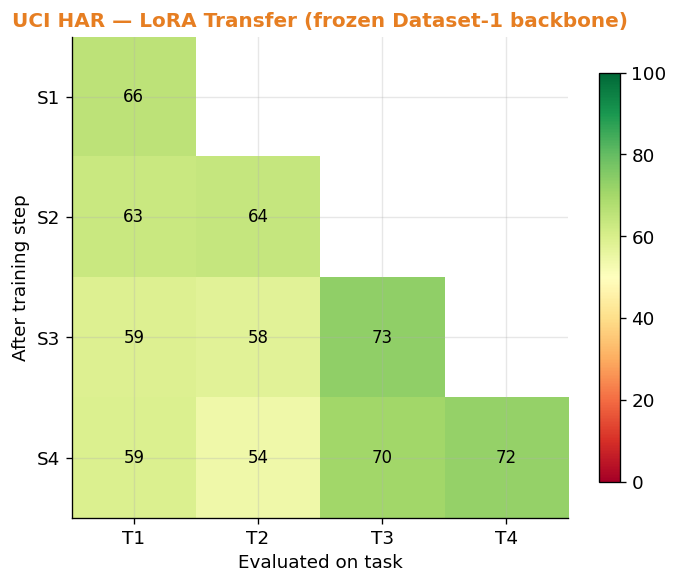

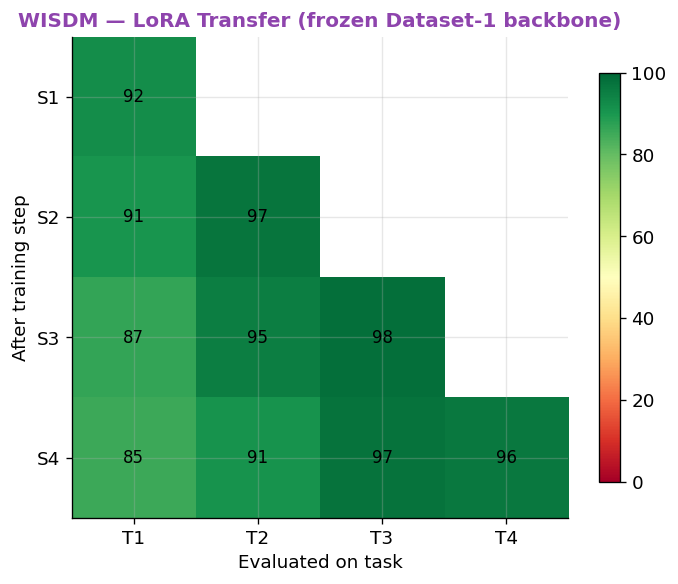

In [16]:
def plot_acc_matrix(acc_matrix, task_names, title, color='#E67E22'):
    n_t = len(task_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    masked = np.ma.masked_invalid(acc_matrix * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xticks(range(n_t)); ax.set_yticks(range(n_t))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_t)])
    ax.set_yticklabels([f'S{i+1}' for i in range(n_t)])
    ax.set_xlabel('Evaluated on task'); ax.set_ylabel('After training step')
    for i in range(n_t):
        for j in range(n_t):
            if not np.isnan(acc_matrix[i, j]):
                v = acc_matrix[i, j] * 100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=10, color='black' if v > 40 else 'white')
    ax.set_title(title, color=color, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


plot_acc_matrix(acc_uci, task_names_uci,
                'UCI HAR — LoRA Transfer (frozen Dataset-1 backbone)')
plot_acc_matrix(acc_wsd, task_names_wsd,
                'WISDM — LoRA Transfer (frozen Dataset-1 backbone)',
                color='#8E44AD')


### 9.2 Summary table

In [20]:
def print_summary(acc_matrix, task_names, dataset_name):
    n_t   = len(task_names)
    t1_i  = acc_matrix[0, 0] * 100
    t1_f  = acc_matrix[-1, 0] * 100
    drop  = t1_i - t1_f
    vals  = [acc_matrix[-1, j] * 100 if not np.isnan(acc_matrix[-1, j]) else 0.0
             for j in range(n_t)]
    avg   = np.nanmean(acc_matrix[-1, :n_t]) * 100
    print(f'\n── {dataset_name} ──────────────────────────────────────')
    header = '  '.join([f'T{j+1}' for j in range(n_t)])
    print(f'  {header}   Avg    T1-drop  T1-init')
    val_s  = '  '.join([f'{v:5.1f}%' for v in vals])
    print(f'  {val_s}  {avg:5.1f}%  {drop:+5.1f}pp  {t1_i:5.1f}%')

    print(f'\n  Per-step accuracy:')
    for i, tn in enumerate(task_names):
        row = '  '.join([f'{acc_matrix[i,j]*100:5.1f}%' if not np.isnan(acc_matrix[i,j])
                         else '   ---' for j in range(n_t)])
        print(f'    After {tn}: {row}')


print_summary(acc_uci, task_names_uci, 'UCI HAR')
print_summary(acc_wsd, task_names_wsd, 'WISDM')



── UCI HAR ──────────────────────────────────────
  T1  T2  T3  T4   Avg    T1-drop  T1-init
   59.2%   54.2%   70.3%   72.5%   64.1%   +6.4pp   65.6%

  Per-step accuracy:
    After Task 1:  65.6%     ---     ---     ---
    After Task 2:  63.2%   63.9%     ---     ---
    After Task 3:  58.8%   57.8%   73.0%     ---
    After Task 4:  59.2%   54.2%   70.3%   72.5%

── WISDM ──────────────────────────────────────
  T1  T2  T3  T4   Avg    T1-drop  T1-init
   85.4%   90.7%   97.5%   96.4%   92.5%   +6.6pp   92.0%

  Per-step accuracy:
    After Task 1:  92.0%     ---     ---     ---
    After Task 2:  90.5%   97.1%     ---     ---
    After Task 3:  86.6%   95.0%   98.3%     ---
    After Task 4:  85.4%   90.7%   97.5%   96.4%


### 9.3 Forgetting curves

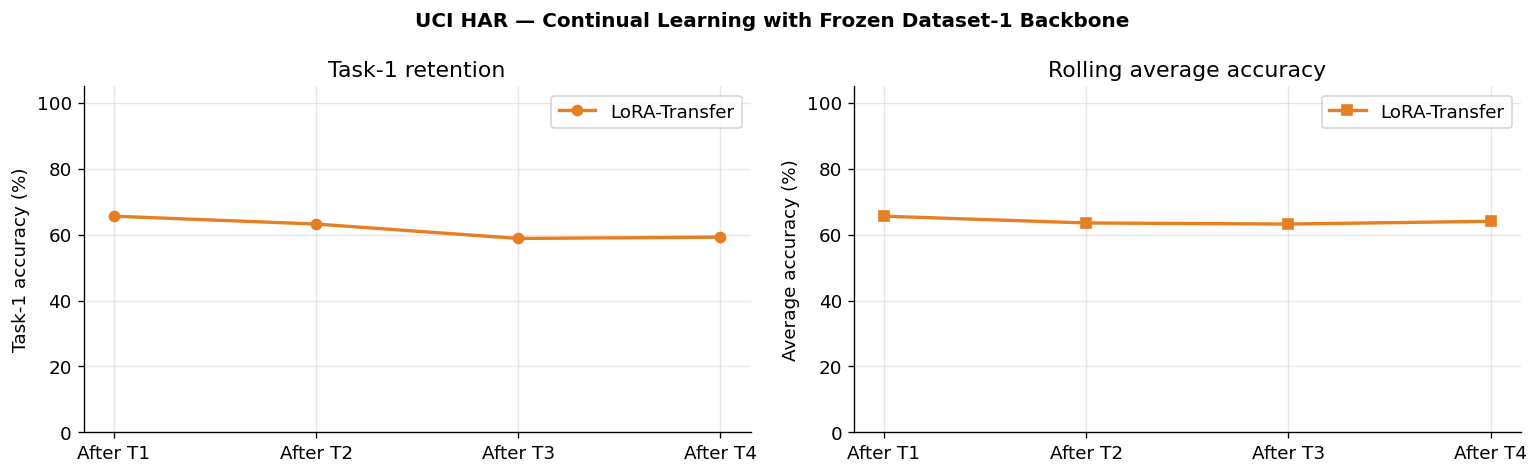

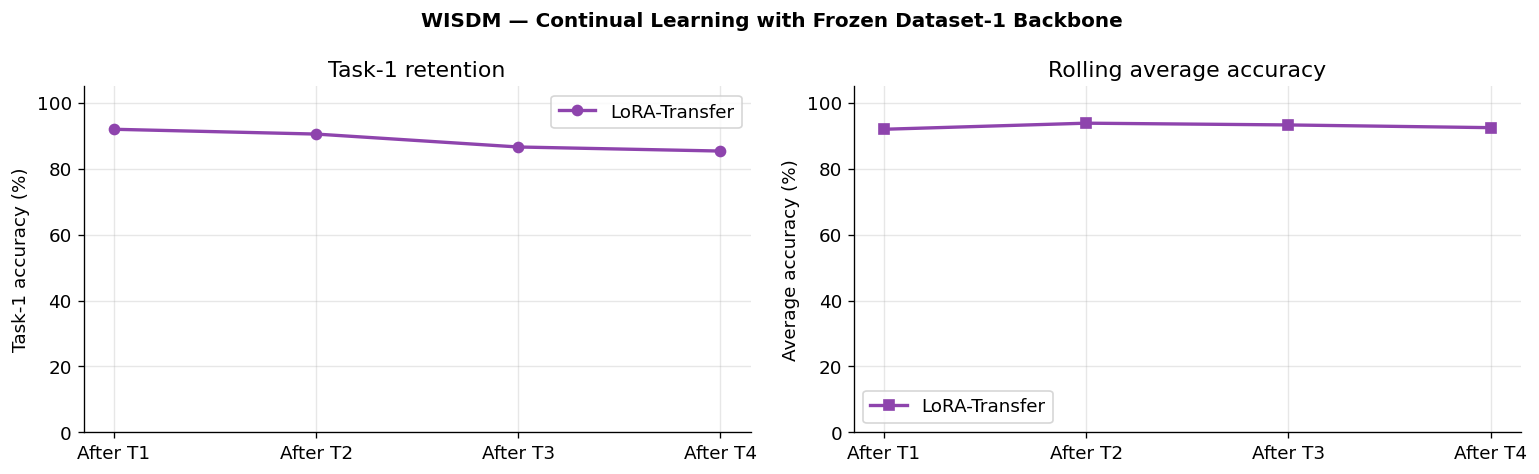

In [21]:
def plot_forgetting_curves(results, title):
    """
    results: list of (label, acc_matrix, color)
    Left panel  : Task-1 accuracy at each step (retention).
    Right panel : Rolling average accuracy at each step.
    """
    n_t   = results[0][1].shape[0]
    steps = list(range(n_t))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for label, mat, color in results:
        t1  = [mat[i, 0] * 100 for i in steps]
        avg = [np.nanmean(mat[i, :i+1]) * 100 for i in steps]
        axes[0].plot(steps, t1,  'o-', color=color, label=label, lw=2)
        axes[1].plot(steps, avg, 's-', color=color, label=label, lw=2)

    for ax, ylabel, ttl in zip(axes,
                                ['Task-1 accuracy (%)', 'Average accuracy (%)'],
                                ['Task-1 retention', 'Rolling average accuracy']):
        ax.set_xticks(steps)
        ax.set_xticklabels([f'After T{i+1}' for i in steps])
        ax.set_ylabel(ylabel); ax.set_title(ttl)
        ax.legend(); ax.set_ylim(0, 105)

    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


plot_forgetting_curves(
    [('LoRA-Transfer', acc_uci, '#E67E22')],
    'UCI HAR — Continual Learning with Frozen Dataset-1 Backbone')

plot_forgetting_curves(
    [('LoRA-Transfer', acc_wsd, '#8E44AD')],
    'WISDM — Continual Learning with Frozen Dataset-1 Backbone')


### 9.4 Parameter budget

In [50]:
flat = 128 * ADAPTIVE_SIZE

cnn_params = sum(p.numel() for p in pretrained_cnn.feature_extractor.parameters())
emb_base   = sum(p.numel() for p in pretrained_cnn.embedding.parameters())
emb_lora   = LORA_RANK * (flat + EMBED_DIM)   # A_k + B_k for embedding
cls_uci    = EMBED_DIM * UCI_N_CLASSES + UCI_N_CLASSES   # weight + bias
cls_wsd    = EMBED_DIM * WSD_N_CLASSES + WSD_N_CLASSES

print('Parameter budget — LoRA Transfer model')
print()
print(f'  {"Component":<35} {"Params":>10}  {"Trained?"}')
print('  ' + '─' * 60)
print(f'  {"CNN feature extractor (frozen)":<35} {cnn_params:>10,}  No  (from Dataset 1)')
print(f'  {"Embedding W (frozen)":<35} {emb_base:>10,}  No  (from Dataset 1)')
print(f'  {"Embedding LoRA per task (Aₖ, Bₖ)":<35} {emb_lora:>10,}  Yes (task-specific)')
print(f'  {"Classifier head — UCI HAR (T1 only)":<35} {cls_uci:>10,}  T1 only')
print(f'  {"Classifier head — WISDM (T1 only)":<35} {cls_wsd:>10,}  T1 only')
print()
print(f'  Tasks 2-4: only {emb_lora:,} LoRA params updated per task')


Parameter budget — LoRA Transfer model

  Component                               Params  Trained?
  ────────────────────────────────────────────────────────────
  CNN feature extractor (frozen)          81,504  No  (from Dataset 1)
  Embedding W (frozen)                   131,200  No  (from Dataset 1)
  Embedding LoRA per task (Aₖ, Bₖ)         9,216  Yes (task-specific)
  Classifier head — UCI HAR (T1 only)      3,870  T1 only
  Classifier head — WISDM (T1 only)        6,579  T1 only

  Tasks 2-4: only 9,216 LoRA params updated per task


## COMMENTO

* l'accuracy nel caso del dataset WISDM è molto migliore rispetto al notebook15. In particolare nel notebook15 si era notato che per uno dei task l'accuracy era notevolmente minore rispetto agli altri. Con questo approccio invece l'accuracy è alta (anche più alta rispetto al notebook15) in tutti i task.
* invece nel caso del dataset UCI HAR questo approccio non porta alcun vantaggio. Forse perchè i dati dei due dataset (quello usato nel pretraining e quello UCIHAR) non sono consistenti e quindi non è efficace.